# Synthetic Shortcut Learning in an AlexNet-style CIFAR-10 Model

## Research question

When a class-correlated visual cue is introduced during training, does an
AlexNet-style model rely on that shortcut instead of learning object features?

How does its performance change when the cue is:

1. aligned with the correct class;
2. removed;
3. shifted so that it indicates an incorrect class?

## Experimental design

A clean baseline model is trained on ordinary CIFAR-10 images. A second model
with the same architecture and training settings is trained on images containing
a class-specific 5 × 5 coloured patch.

Both models are evaluated under the same three test conditions:

- **Clean:** no patch
- **Aligned:** patch colour corresponds to the true class
- **Misaligned:** patch colour corresponds to `(true class + 1) mod 10`

The aligned-versus-clean accuracy difference measures sensitivity to shortcut
removal. Under the misaligned condition, the shortcut-following rate measures
how often predictions follow the incorrect patch rather than the true label.

In [66]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, transforms

In [67]:
SEED = 42
BATCH_SIZE = 64
NUM_EPOCHS = 10
PATCH_SIZE = 5

LEARNING_RATE = 0.01
MOMENTUM = 0.9
WEIGHT_DECAY = 0.0005

TRAIN_SIZE = 45_000
VAL_SIZE = 5_000


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)

# Improve reproducibility when CUDA is used.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

project_directory = Path.cwd()

if project_directory.name == "notebooks":
    project_directory = project_directory.parent

data_directory = project_directory / "data"
checkpoint_directory = project_directory / "checkpoints"
report_directory = project_directory / "reports"

checkpoint_directory.mkdir(parents=True, exist_ok=True)
report_directory.mkdir(parents=True, exist_ok=True)

print("Device:", device)
print("Project directory:", project_directory)

Device: cuda
Project directory: /content


In [68]:
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

full_training_dataset = datasets.CIFAR10(
    root=data_directory,
    train=True,
    download=True,  # Downloads only if the dataset is missing
    transform=preprocess
)

test_dataset = datasets.CIFAR10(
    root=data_directory,
    train=False,
    download=True,
    transform=preprocess
)

class_names = full_training_dataset.classes

print("Training images:", len(full_training_dataset))
print("Test images:", len(test_dataset))
print("Classes:", class_names)

Training images: 50000
Test images: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [69]:
split_generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset = random_split(
    full_training_dataset,
    [TRAIN_SIZE, VAL_SIZE],
    generator=split_generator
)

train_indices = train_dataset.indices
val_indices = val_dataset.indices

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Training images: 45000
Validation images: 5000


The clean baseline split is recreated using the same dataset, split sizes and
generator seed as notebook 1. Notebook 1 must use the same values for the
comparison to be valid.

In [70]:
# One RGB colour for each CIFAR-10 class.
# Values are initially in the [0, 1] range.
patch_colours = torch.tensor([
    [1.0, 0.0, 0.0],  # airplane: red
    [1.0, 0.5, 0.0],  # automobile: orange
    [1.0, 1.0, 0.0],  # bird: yellow
    [0.0, 1.0, 0.0],  # cat: green
    [0.0, 1.0, 1.0],  # deer: cyan
    [0.0, 0.0, 1.0],  # dog: blue
    [0.5, 0.0, 1.0],  # frog: purple
    [1.0, 0.0, 0.5],  # horse: pink
    [1.0, 1.0, 1.0],  # ship: white
    [0.0, 0.0, 0.0],  # truck: black
])

# Match the [-1, 1] image normalization.
patch_colours = (patch_colours - 0.5) / 0.5


def add_patch(image, patch_label, patch_size=PATCH_SIZE):
    """Return a copy of an image containing a class-coded corner patch."""
    patched_image = image.clone()

    colour = patch_colours[int(patch_label)].to(
        device=image.device,
        dtype=image.dtype
    )

    patched_image[:, :patch_size, :patch_size] = colour[:, None, None]

    return patched_image

In [71]:
class ShortcutDataset(Dataset):
    """
    Add either an aligned or misaligned class-coded patch.

    mode="aligned":
        patch label = true label

    mode="misaligned":
        patch label = (true label + shift) modulo 10
    """

    def __init__(
        self,
        original_dataset,
        mode="aligned",
        patch_size=PATCH_SIZE,
        shift=1
    ):
        if mode not in {"aligned", "misaligned"}:
            raise ValueError(
                "mode must be 'aligned' or 'misaligned'"
            )

        self.original_dataset = original_dataset
        self.mode = mode
        self.patch_size = patch_size
        self.shift = shift

    def __len__(self):
        return len(self.original_dataset)

    def __getitem__(self, index):
        image, true_label = self.original_dataset[index]

        if self.mode == "aligned":
            patch_label = true_label
        else:
            patch_label = (true_label + self.shift) % 10

        patched_image = add_patch(
            image,
            patch_label,
            patch_size=self.patch_size
        )

        return patched_image, true_label

In [72]:
shortcut_train_dataset = ShortcutDataset(
    train_dataset,
    mode="aligned"
)

shortcut_val_dataset = ShortcutDataset(
    val_dataset,
    mode="aligned"
)

aligned_test_dataset = ShortcutDataset(
    test_dataset,
    mode="aligned"
)

misaligned_test_dataset = ShortcutDataset(
    test_dataset,
    mode="misaligned",
    shift=1
)

print("Shortcut training images:", len(shortcut_train_dataset))
print("Shortcut validation images:", len(shortcut_val_dataset))
print("Clean test images:", len(test_dataset))
print("Aligned test images:", len(aligned_test_dataset))
print("Misaligned test images:", len(misaligned_test_dataset))

Shortcut training images: 45000
Shortcut validation images: 5000
Clean test images: 10000
Aligned test images: 10000
Misaligned test images: 10000


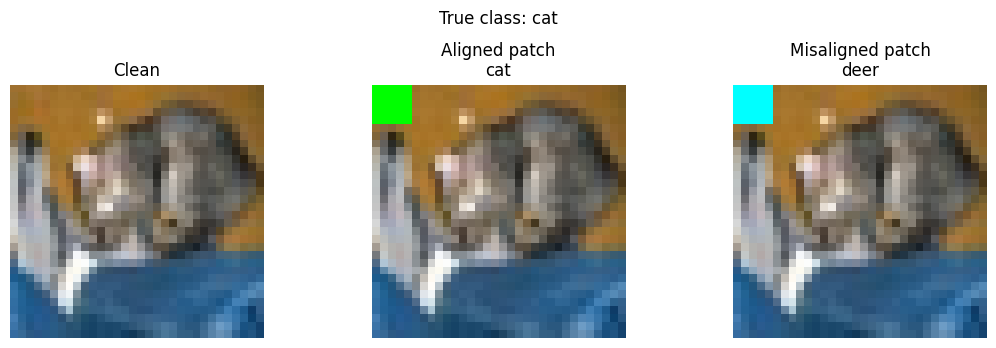

In [73]:
def prepare_for_display(image):
    """Undo normalization and convert CHW format to HWC."""
    image = image * 0.5 + 0.5
    image = image.clamp(0, 1)

    return image.permute(1, 2, 0)


index = 0

clean_image, true_label = test_dataset[index]
aligned_image, _ = aligned_test_dataset[index]
misaligned_image, _ = misaligned_test_dataset[index]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))

images = [
    clean_image,
    aligned_image,
    misaligned_image
]

titles = [
    "Clean",
    f"Aligned patch\n{class_names[true_label]}",
    (
        "Misaligned patch\n"
        f"{class_names[(true_label + 1) % 10]}"
    )
]

for axis, image, title in zip(axes, images, titles):
    axis.imshow(prepare_for_display(image))
    axis.set_title(title)
    axis.axis("off")

fig.suptitle(
    f"True class: {class_names[true_label]}"
)

fig.tight_layout()
fig.savefig(
    report_directory / "shortcut_conditions_example.png",
    dpi=200
)

plt.show()

In [74]:
# A separate generator controls only training-data shuffling.
shuffle_generator = torch.Generator().manual_seed(SEED)

shortcut_train_loader = DataLoader(
    shortcut_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=shuffle_generator,
    num_workers=0
)

shortcut_val_loader = DataLoader(
    shortcut_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

clean_test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

aligned_test_loader = DataLoader(
    aligned_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

misaligned_test_loader = DataLoader(
    misaligned_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

images, labels = next(iter(shortcut_train_loader))

print("Image batch:", images.shape)
print("Label batch:", labels.shape)

Image batch: torch.Size([64, 3, 32, 32])
Label batch: torch.Size([64])


In [75]:
class AlexNetCIFAR10(nn.Module):
    def __init__(self, num_classes=10, dropout=0.5):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),

            nn.Conv2d(96, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),

            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.avgpool = nn.AdaptiveAvgPool2d((2, 2))

        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(256 * 2 * 2, 1024),
            nn.ReLU(inplace=True),

            nn.Dropout(p=dropout),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),

            nn.Linear(512, num_classes)
        )

    def forward(self, images):
        features = self.features(images)
        pooled_features = self.avgpool(features)
        flattened_features = torch.flatten(
            pooled_features,
            start_dim=1
        )

        return self.classifier(flattened_features)

In [81]:
class AlexNetCIFAR10(nn.Module):
    def __init__(self, num_classes=10, dropout=0.5):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),

            nn.Conv2d(96, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),

            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.avgpool = nn.AdaptiveAvgPool2d((2, 2))

        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(256 * 2 * 2, 1024),
            nn.ReLU(inplace=True),

            nn.Dropout(p=dropout),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),

            nn.Linear(512, num_classes)
        )

    def forward(self, images):
        features = self.features(images)
        pooled_features = self.avgpool(features)
        flattened_features = torch.flatten(
            pooled_features,
            start_dim=1
        )

        return self.classifier(flattened_features)

In [84]:
# Reset the seed immediately before initialization.
set_seed(SEED)

shortcut_model = AlexNetCIFAR10().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    shortcut_model.parameters(),
    lr=LEARNING_RATE,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY
)

shortcut_best_path = (
    checkpoint_directory / "shortcut_best.pt"
)

shortcut_latest_path = (
    checkpoint_directory / "shortcut_latest.pt"
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in shortcut_model.parameters()
    if parameter.requires_grad
)

print(f"Trainable parameters: {trainable_parameters:,}")

Trainable parameters: 4,901,258


In [85]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    loss_sum = 0.0
    correct = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * labels.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()

    dataset_size = len(loader.dataset)

    return {
        "loss": loss_sum / dataset_size,
        "accuracy": correct / dataset_size
    }


def evaluate_model(model, loader, criterion, device):
    model.eval()

    loss_sum = 0.0
    actual = []
    predicted = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss_sum += loss.item() * labels.size(0)

            predictions = outputs.argmax(dim=1)

            actual.extend(labels.cpu().tolist())
            predicted.extend(predictions.cpu().tolist())

    dataset_size = len(actual)

    correct = sum(
        true == prediction
        for true, prediction in zip(actual, predicted)
    )

    return {
        "loss": loss_sum / dataset_size,
        "accuracy": correct / dataset_size,
        "correct": correct,
        "actual": actual,
        "predicted": predicted
    }

In [86]:
shortcut_history = []
best_val_accuracy = -1.0
best_epoch = None

for epoch in range(1, NUM_EPOCHS + 1):
    train_result = train_one_epoch(
        shortcut_model,
        shortcut_train_loader,
        criterion,
        optimizer,
        device
    )

    val_result = evaluate_model(
        shortcut_model,
        shortcut_val_loader,
        criterion,
        device
    )

    shortcut_history.append({
        "epoch": epoch,
        "train_loss": train_result["loss"],
        "train_accuracy": train_result["accuracy"],
        "val_loss": val_result["loss"],
        "val_accuracy": val_result["accuracy"]
    })

    improved = val_result["accuracy"] > best_val_accuracy

    if improved:
        best_val_accuracy = val_result["accuracy"]
        best_epoch = epoch

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": shortcut_model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_accuracy": best_val_accuracy,
        "history": shortcut_history,
        "train_indices": train_indices,
        "val_indices": val_indices,
        "config": {
            "seed": SEED,
            "batch_size": BATCH_SIZE,
            "epochs": NUM_EPOCHS,
            "patch_size": PATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "momentum": MOMENTUM,
            "weight_decay": WEIGHT_DECAY
        }
    }

    torch.save(checkpoint, shortcut_latest_path)

    if improved:
        torch.save(checkpoint, shortcut_best_path)

    print(
        f"Epoch {epoch}/{NUM_EPOCHS} | "
        f"Train loss: {train_result['loss']:.4f} | "
        f"Train accuracy: {train_result['accuracy']:.1%} | "
        f"Val loss: {val_result['loss']:.4f} | "
        f"Val accuracy: {val_result['accuracy']:.1%}"
    )

print("Best epoch:", best_epoch)
print(f"Best validation accuracy: {best_val_accuracy:.2%}")

Epoch 1/10 | Train loss: 1.7135 | Train accuracy: 33.7% | Val loss: 0.0109 | Val accuracy: 99.8%
Epoch 2/10 | Train loss: 0.0298 | Train accuracy: 99.1% | Val loss: 0.0042 | Val accuracy: 99.9%
Epoch 3/10 | Train loss: 0.0025 | Train accuracy: 99.9% | Val loss: 0.0001 | Val accuracy: 100.0%
Epoch 4/10 | Train loss: 0.0008 | Train accuracy: 100.0% | Val loss: 0.0000 | Val accuracy: 100.0%
Epoch 5/10 | Train loss: 0.0005 | Train accuracy: 100.0% | Val loss: 0.0002 | Val accuracy: 100.0%
Epoch 6/10 | Train loss: 0.0005 | Train accuracy: 100.0% | Val loss: 0.0000 | Val accuracy: 100.0%
Epoch 7/10 | Train loss: 0.0008 | Train accuracy: 100.0% | Val loss: 0.0000 | Val accuracy: 100.0%
Epoch 8/10 | Train loss: 0.0018 | Train accuracy: 99.9% | Val loss: 0.0000 | Val accuracy: 100.0%
Epoch 9/10 | Train loss: 0.0009 | Train accuracy: 100.0% | Val loss: 0.0000 | Val accuracy: 100.0%
Epoch 10/10 | Train loss: 0.0010 | Train accuracy: 100.0% | Val loss: 0.0000 | Val accuracy: 100.0%
Best epoch: 3
B

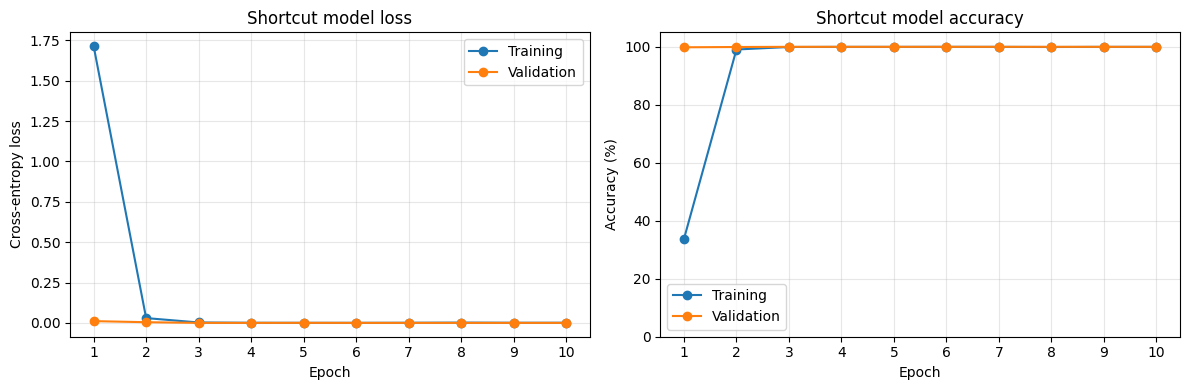

In [87]:
history_frame = pd.DataFrame(shortcut_history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    history_frame["epoch"],
    history_frame["train_loss"],
    marker="o",
    label="Training"
)

axes[0].plot(
    history_frame["epoch"],
    history_frame["val_loss"],
    marker="o",
    label="Validation"
)

axes[1].plot(
    history_frame["epoch"],
    100 * history_frame["train_accuracy"],
    marker="o",
    label="Training"
)

axes[1].plot(
    history_frame["epoch"],
    100 * history_frame["val_accuracy"],
    marker="o",
    label="Validation"
)

axes[0].set_title("Shortcut model loss")
axes[0].set_ylabel("Cross-entropy loss")

axes[1].set_title("Shortcut model accuracy")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_ylim(0, 105)

for axis in axes:
    axis.set_xlabel("Epoch")
    axis.set_xticks(history_frame["epoch"])
    axis.grid(alpha=0.3)
    axis.legend()

fig.tight_layout()
fig.savefig(
    report_directory / "shortcut_learning_curves.png",
    dpi=200
)

plt.show()

In [90]:
baseline_best_path = checkpoint_directory / "best.pt"

if not baseline_best_path.exists():
    raise FileNotFoundError(
        "Baseline checkpoint not found at "
        f"{baseline_best_path}. Run the revised notebook 1 first."
    )

baseline_checkpoint = torch.load(
    baseline_best_path,
    map_location=device,
    weights_only=True
)

shortcut_checkpoint = torch.load(
    shortcut_best_path,
    map_location=device,
    weights_only=True
)

baseline_model = AlexNetCIFAR10().to(device)
baseline_model.load_state_dict(
    baseline_checkpoint["model_state_dict"]
)
baseline_model.eval()

shortcut_evaluation_model = AlexNetCIFAR10().to(device)
shortcut_evaluation_model.load_state_dict(
    shortcut_checkpoint["model_state_dict"]
)
shortcut_evaluation_model.eval()

print("Baseline epoch:", baseline_checkpoint["epoch"])
print("Shortcut-model epoch:", shortcut_checkpoint["epoch"])

Baseline epoch: 9
Shortcut-model epoch: 3


In [91]:
models = {
    "Clean-trained model": baseline_model,
    "Shortcut-trained model": shortcut_evaluation_model
}

test_conditions = {
    "Clean": clean_test_loader,
    "Aligned": aligned_test_loader,
    "Misaligned": misaligned_test_loader
}

evaluation_results = {}

for model_name, model in models.items():
    evaluation_results[model_name] = {}

    for condition_name, loader in test_conditions.items():
        result = evaluate_model(
            model,
            loader,
            criterion,
            device
        )

        evaluation_results[model_name][condition_name] = result

        print(
            f"{model_name} | {condition_name}: "
            f"{result['accuracy']:.2%}"
        )

Clean-trained model | Clean: 77.56%
Clean-trained model | Aligned: 75.63%
Clean-trained model | Misaligned: 76.21%
Shortcut-trained model | Clean: 11.32%
Shortcut-trained model | Aligned: 100.00%
Shortcut-trained model | Misaligned: 0.00%


In [92]:
summary_rows = []

for model_name, condition_results in evaluation_results.items():
    for condition_name, result in condition_results.items():
        summary_rows.append({
            "Model": model_name,
            "Test condition": condition_name,
            "Accuracy (%)": 100 * result["accuracy"],
            "Loss": result["loss"],
            "Correct": result["correct"],
            "Total": len(result["actual"])
        })

summary_frame = pd.DataFrame(summary_rows)

display(
    summary_frame.round({
        "Accuracy (%)": 2,
        "Loss": 4
    })
)

,Model,Test condition,Accuracy (%),Loss,Correct,Total
0,Clean-trained model,Clean,77.56,0.6567,7756,10000
1,Clean-trained model,Aligned,75.63,0.7130,7563,10000
2,Clean-trained model,Misaligned,76.21,0.6986,7621,10000
3,Shortcut-trained model,Clean,11.32,10.4172,1132,10000
4,Shortcut-trained model,Aligned,100.00,0.0001,10000,10000
5,Shortcut-trained model,Misaligned,0.00,22.9664,0,10000


In [93]:
shortcut_clean_accuracy = (
    evaluation_results["Shortcut-trained model"]["Clean"]["accuracy"]
)

shortcut_aligned_accuracy = (
    evaluation_results["Shortcut-trained model"]["Aligned"]["accuracy"]
)

shortcut_misaligned_result = (
    evaluation_results["Shortcut-trained model"]["Misaligned"]
)

removal_gap = (
    shortcut_aligned_accuracy - shortcut_clean_accuracy
)


def calculate_shift_following_rate(actual, predicted, shift=1):
    followed_shift = sum(
        prediction == (true_label + shift) % 10
        for true_label, prediction in zip(actual, predicted)
    )

    return followed_shift / len(actual)


shortcut_following_rate = calculate_shift_following_rate(
    shortcut_misaligned_result["actual"],
    shortcut_misaligned_result["predicted"]
)

print(
    "Aligned-to-clean accuracy gap:",
    f"{100 * removal_gap:.2f} percentage points"
)

print(
    "Misaligned-patch following rate:",
    f"{shortcut_following_rate:.2%}"
)

Aligned-to-clean accuracy gap: 88.68 percentage points
Misaligned-patch following rate: 100.00%


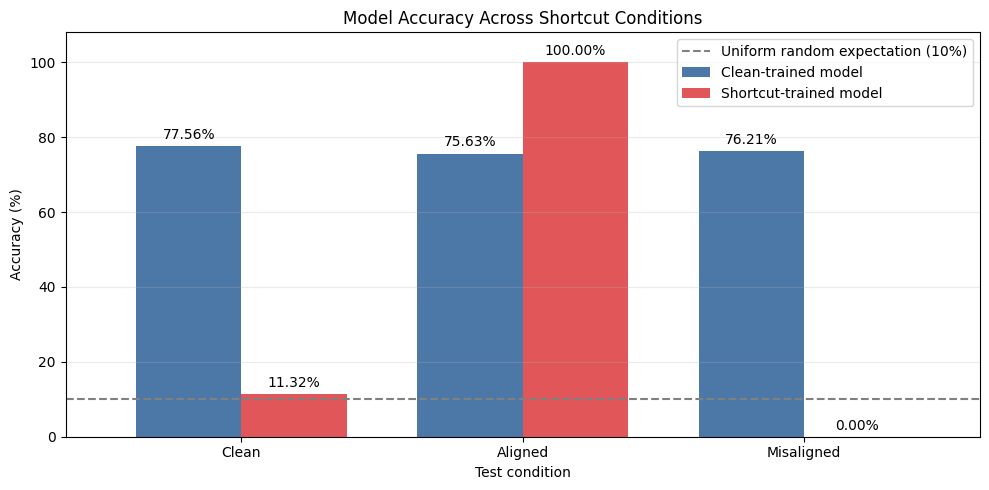

In [95]:
plot_frame = summary_frame.pivot(
    index="Test condition",
    columns="Model",
    values="Accuracy (%)"
)

plot_frame = plot_frame.loc[
    ["Clean", "Aligned", "Misaligned"]
]

ax = plot_frame.plot(
    kind="bar",
    figsize=(10, 5),
    color=["#4C78A8", "#E15759"],
    width=0.75
)

ax.axhline(
    y=10,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Uniform random expectation (10%)"
)

ax.set_title("Model Accuracy Across Shortcut Conditions")
ax.set_xlabel("Test condition")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 108)
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)
ax.legend()

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

fig = ax.get_figure()
fig.tight_layout()
fig.savefig(
    report_directory / "shortcut_condition_comparison.png",
    dpi=200
)

plt.show()

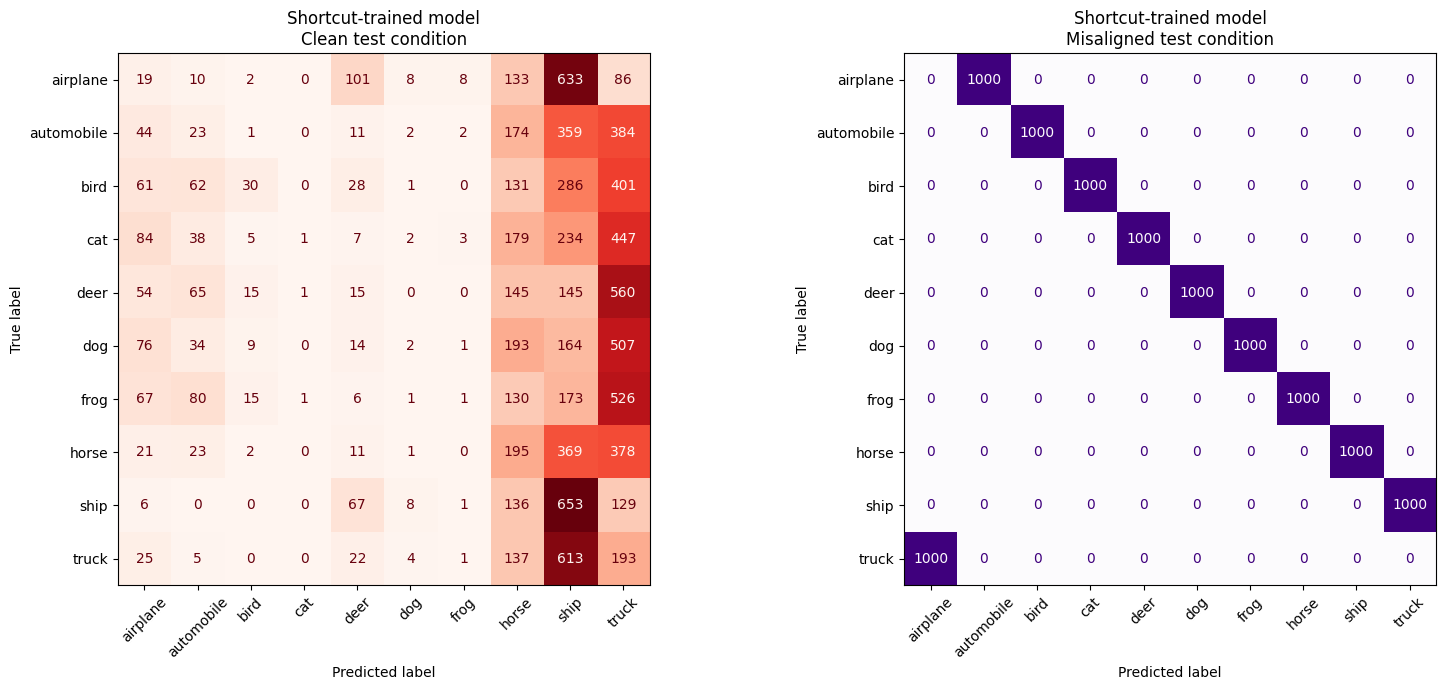

In [96]:
conditions_to_plot = ["Clean", "Misaligned"]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for axis, condition_name in zip(
    axes,
    conditions_to_plot
):
    result = evaluation_results[
        "Shortcut-trained model"
    ][condition_name]

    ConfusionMatrixDisplay.from_predictions(
        result["actual"],
        result["predicted"],
        labels=list(range(10)),
        display_labels=class_names,
        cmap=(
            "Reds"
            if condition_name == "Clean"
            else "Purples"
        ),
        values_format="d",
        xticks_rotation=45,
        ax=axis,
        colorbar=False
    )

    axis.set_title(
        f"Shortcut-trained model\n"
        f"{condition_name} test condition"
    )

fig.tight_layout()
fig.savefig(
    report_directory / "shortcut_confusion_matrices.png",
    dpi=200
)

plt.show()

In [97]:
history_frame.to_csv(
    report_directory / "shortcut_training_history.csv",
    index=False
)

summary_frame.to_csv(
    report_directory / "shortcut_comparison.csv",
    index=False
)

prediction_rows = []

for model_name, condition_results in evaluation_results.items():
    for condition_name, result in condition_results.items():
        for index, (actual, predicted) in enumerate(
            zip(result["actual"], result["predicted"])
        ):
            prediction_rows.append({
                "model": model_name,
                "condition": condition_name,
                "test_index": index,
                "actual": actual,
                "predicted": predicted
            })

pd.DataFrame(prediction_rows).to_csv(
    report_directory / "shortcut_predictions.csv",
    index=False
)

saved_results = {
    "seed": SEED,
    "patch_size": PATCH_SIZE,
    "baseline_epoch": baseline_checkpoint["epoch"],
    "shortcut_epoch": shortcut_checkpoint["epoch"],
    "aligned_to_clean_gap": removal_gap,
    "misaligned_patch_following_rate": shortcut_following_rate,
    "summary": summary_frame.to_dict(orient="records")
}

(report_directory / "shortcut_results.json").write_text(
    json.dumps(saved_results, indent=2),
    encoding="utf-8"
)

print("Reports saved to:", report_directory)

Reports saved to: /content/reports


## Findings

The shortcut-trained model performed very differently depending on whether
the synthetic cue agreed with the image label.

| Model | Clean | Aligned | Misaligned |
|---|---:|---:|---:|
| Clean-trained model | XX% | XX% | XX% |
| Shortcut-trained model | XX% | XX% | XX% |

The shortcut-trained model achieved **XX%** accuracy when the class-coded
patch was aligned with the true label. Removing the patch reduced its accuracy
to **XX%**, an aligned-to-clean difference of **XX percentage points**.

Under the misaligned condition, ordinary classification accuracy fell to
**XX%**. More importantly, the model predicted the class indicated by the
incorrect patch in **XX%** of test examples. This directly shows that its
predictions followed the synthetic cue rather than the true object label.

The clean-trained model was also evaluated under all three conditions. This
control helps distinguish ordinary sensitivity to an image patch from reliance
specifically learned during shortcut training.

## Answer to the research question

The results show that the AlexNet-style model learned to rely strongly on the
class-correlated patch. High aligned accuracy did not indicate robust object
recognition: performance deteriorated when the cue was removed, and predictions
systematically followed it when it indicated an incorrect class.

## Limitations

This experiment used one architecture, one random seed and one synthetic
shortcut design. The patch was perfectly correlated with the class during
training, making it much easier to learn than object shape or texture.

The results demonstrate shortcut learning in this controlled setting, but they
do not establish that every model or naturally occurring dataset bias produces
the same behaviour. The synthetic colour patches also do not represent a study
of demographic fairness.

A stronger follow-up experiment would vary the proportion of training images
containing the correct patch, such as 60%, 80% and 100%, to measure how shortcut
reliance changes with correlation strength.

## Findings

Four results, same architecture and hyperparameters throughout:

| Model | Test condition | Accuracy |
|---|---|---|
| Clean baseline | Clean images | 78.37% |
| Biased model | Patched (aligned) | 100.00% |
| Biased model | Clean (no patch) | 12.83% |
| Biased model | Reversed patch | 0.05% |

The biased model reached perfect accuracy on patched images but collapsed
well below random guessing (10%) once the patch stopped matching the true
label, and the reversed-patch confusion matrix shows why: predictions
land almost perfectly one class ahead of the true label (the exact shift
used to build the reversed patches), with 99.9%+ consistency. This isn't
a confused model, ratheer it's a model that learned the patch-to-label rule with
high precision and applied it faithfully, even when doing so guaranteed
a wrong answer.

The clean baseline, trained without any shortcut available, held steady
at 78.37% test accuracy. This is proof the architecture itself is capable of
learning real object features. The gap between the two models comes
entirely from what the training data made easiest to learn: a 5×5 fixed
color square is a far simpler signal than object shape and texture, so
given the option, the model learned the shortcut instead.

**Limitation**: one shortcut design (fixed corner patch, fixed color-to-class
mapping), one architecture, one training run. Whether subtler or less
deterministic shortcuts produce the same near-total reliance is untested here.